# Operacje na tensorach

In [136]:
import torch

In [137]:
device = "cuda" if torch.cuda.is_available() else 'cpu'

---

In [138]:
rand_tensor = torch.randn((4,2))
rand_tensor

tensor([[-0.1349, -1.8722],
        [-0.2410, -0.1703],
        [-0.4294,  0.0772],
        [ 1.7164,  0.0681]])

In [139]:
zero_tensor = torch.zeros((1,4))
zero_tensor

tensor([[0., 0., 0., 0.]])

In [140]:
ones_tensor = torch.ones(7)
ones_tensor


tensor([1., 1., 1., 1., 1., 1., 1.])

---

> torch.tensor(t) == t.detach().clone() 

> torch.tensor(t,requires_grad = True) == t.detach().clone().requires_grad_(True)


In [141]:
mul1 = torch.tensor([[1,2],[3,4]])
mul2 = torch.tensor([[2,0],[3,1]])

display(mul1,mul2)

tensor([[1, 2],
        [3, 4]])

tensor([[2, 0],
        [3, 1]])

In [142]:
mul1 + mul2

tensor([[3, 2],
        [6, 5]])

In [143]:
mul1 * mul2

tensor([[2, 0],
        [9, 4]])

In [144]:
mul1

tensor([[1, 2],
        [3, 4]])

In [145]:
mul2

tensor([[2, 0],
        [3, 1]])

In [146]:
mul1 @ mul2

tensor([[ 8,  2],
        [18,  4]])

---

In [147]:
test1 = torch.tensor([[1,2],[3,4]])
test1

tensor([[1, 2],
        [3, 4]])

In [148]:
test2 = torch.as_tensor([[1,2],[3,4]])
test2

tensor([[1, 2],
        [3, 4]])

---

In [149]:
test3 = torch.tensor([[1,2],[3,4]],dtype=torch.float32 ,requires_grad=True, device=device)
tensor_2_numpy = test3.detach().cpu().numpy()

In [150]:
type(tensor_2_numpy)

numpy.ndarray

In [151]:
#test3 + tensor_2_numpy

---

In [152]:
def mean_and_std(tensor:torch.Tensor) -> tuple[float,float]:
    tensor = tensor.to(device)
    mean = torch.mean(tensor)
    std = torch.std(tensor)

    print(f"Mean: {mean}, Std: {std}")

    return mean.item(), std.item()

In [153]:
mean_and_std(rand_tensor)

Mean: -0.12325286865234375, Std: 0.9731974005699158


(-0.12325286865234375, 0.9731974005699158)

---

In [154]:
from tqdm import tqdm

In [155]:
x = torch.randn((2,3), dtype=torch.float32)
print(f"x: {x}")
noise = torch.rand((2,3))
print(f"noise: {noise}")

x: tensor([[ 1.6090, -0.6245,  2.2301],
        [-0.0267,  1.9154, -0.8089]])
noise: tensor([[0.6102, 0.6852, 0.7211],
        [0.1064, 0.9853, 0.7631]])


In [156]:
y = 2 * x + 1 + noise
y

tensor([[4.8282, 0.4361, 6.1813],
        [1.0530, 5.8161, 0.1453]])

In [157]:
def MSE(y_true:torch.Tensor,y_hat:torch.Tensor) -> torch.Tensor:
    # MSE = 1/n * sum((y_hat - y_true)**2)
    n: int = len(y_true)

    mse = torch.tensor(1.0) / torch.tensor(n) * torch.sum((y_hat - y_true)**2)

    return mse



In [160]:
n_epoch = 1000
lr = 0.01

w = torch.rand(1, dtype=x.dtype, device=x.device)
b = torch.rand(1, dtype=x.dtype, device=x.device)

print(f"w: {w}, b: {b}")

n = len(x)
losses = []

for epoch in tqdm(range(n_epoch),desc="Training."):
    # Function = b + w * x  
    yhat = b + w * x
    loss = MSE(y, yhat)
    losses.append(loss.item())
    # Loss = 1/n * sum((yhat - y)**2) 
    # dL/db = 2/n * sum(yhat - y)
    # dL/dw = 2/n * sum((yhat - y) * x)
    
    error = yhat - y
    grad_b = (2/n) * torch.sum(error)
    grad_w = (2/n) * torch.sum(error * x)

    b = b - lr * grad_b
    w = w - lr * grad_w

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.6f}, w: {w.item():.4f}, b: {b.item():.4f}")

print(f"Final w: {w}, Final b: {b}")


w: tensor([0.8199]), b: tensor([0.8073])


Training.: 100%|██████████| 1000/1000 [00:00<00:00, 9389.62it/s]

Epoch: 0, loss: 15.891814, w: 1.0073, b: 0.9083
Epoch: 100, loss: 0.190692, w: 2.0727, b: 1.5917
Epoch: 200, loss: 0.190678, w: 2.0716, b: 1.5940
Epoch: 300, loss: 0.190678, w: 2.0715, b: 1.5940
Epoch: 400, loss: 0.190678, w: 2.0715, b: 1.5940
Epoch: 500, loss: 0.190678, w: 2.0715, b: 1.5940
Epoch: 600, loss: 0.190678, w: 2.0715, b: 1.5940
Epoch: 700, loss: 0.190678, w: 2.0715, b: 1.5940
Epoch: 800, loss: 0.190678, w: 2.0715, b: 1.5940
Epoch: 900, loss: 0.190678, w: 2.0715, b: 1.5940
Final w: tensor([2.0715]), Final b: tensor([1.5940])


In [ ]:
import matplotlib.pyplot as plt

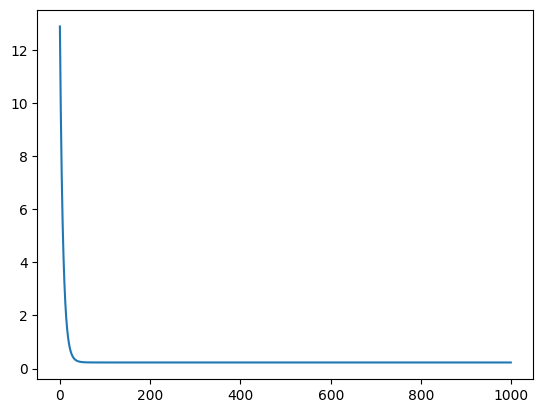

In [ ]:
plt.plot(losses)
plt.show()